In [1]:
import shap
import torch
import numpy as np
from torch import nn
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

/home/set/miniconda3/envs/torchPL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class LSTM(nn.Module):
    def __init__(self,input_size,hidden_size, dropout,num_layer,output_features):
        super(LSTM,self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.num_layer = num_layer
        self.output_features = output_features
        self.lstm = nn.LSTM(input_size=self.input_size,
                            hidden_size=self.hidden_size,
                            dropout =self.dropout,
                            num_layers=self.num_layer,
                            bias=True,
                            batch_first=True,
                            bidirectional=False)
        # We use last output value which has size like this for the prediction, since the size of each output in output value is (B,H)
        # The same as ct and ht                    
        self.output = nn.Linear(in_features=self.hidden_size, out_features=self.output_features)
    
    def forward(self, X):
        # Because output(B,H) of each t, which is the size of ct and ht, so we want the start ct and ht like this
        cell_state = torch.zeros(size=(self.num_layer, X.size(0), self.hidden_size), device=X.device)
        hidden_state = torch.zeros(size=(self.num_layer, X.size(0), self.hidden_size), device=X.device)
        # Return output,(hn,cn), but we just care about the output value
        out,_ = self.lstm(X,(hidden_state,cell_state))
        # We just want to use the last output value
        return self.output(out[:,-1,:])

In [3]:
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda', index=2)

In [5]:
def shapValue(model, XBackground, XTest, bandList):
    explainer = shap.GradientExplainer(model, XBackground)
    # (sample, timeStamps, features, outputs shape) -> (features)
    shapValues = np.mean(explainer(XTest).values.squeeze(-1),axis=1)
    barImage = shap.Explanation(
        values= shapValues.squeeze(),
        feature_names= bandList
    )

    shap.summary_plot(shapValues,feature_names= bandList, plot_type="bar")
    return barImage

In [6]:
modelPath = "/sdd/Dubaoset/src/Phong/Model/LSTM6Output_Way1/shapTunned.pth"


In [7]:
myModel = LSTM(input_size= 15, hidden_size= 256, dropout= 0.2, num_layer= 2, output_features= 1).to(device)

In [8]:
myModel.load_state_dict(torch.load(modelPath, map_location= device))

<All keys matched successfully>

In [47]:
import random

In [61]:
singleBand = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB']
diffBand = ["IRB-I2B", "WVB-B14B","WVB-IRB","B11B-B12B","B11B-IRB"]
bandList = singleBand + diffBand

In [62]:
bandList

['B09B',
 'B10B',
 'B11B',
 'B12B',
 'B14B',
 'B16B',
 'I2B',
 'I4B',
 'IRB',
 'WVB',
 'IRB-I2B',
 'WVB-B14B',
 'WVB-IRB',
 'B11B-B12B',
 'B11B-IRB']

In [63]:
startPeriodTrain = -6
endPeriodTrain = 0
bandTypeTrain = [
    f"{band}_t{i:+d}" if band != "Dem_value" else "Dem_value"
    for i in range(startPeriodTrain, endPeriodTrain)
    for band in bandList
]

In [64]:
XTrain = pl.read_parquet("/sdd/Dubaoset/src/Phong/Source/addInput/X/X_merged_data_part_0.parquet").to_pandas()

In [65]:
XBackground = XTrain.loc[:2000, bandTypeTrain]

In [66]:
XBackground = torch.tensor(XBackground.values.reshape(-1,6,15), device=device)

In [67]:
XBackground.shape

torch.Size([2001, 6, 15])

In [68]:
XDataTest = pl.read_parquet("/sdd/Dubaoset/src/Phong/Source/addInput/XTest/X_merged_data_part_0.parquet").to_pandas()

In [69]:
XTest = XDataTest.loc[:2000, bandTypeTrain]

In [70]:
XTest = torch.tensor(XTest.values.reshape(-1,6,15), device=device)

In [71]:
XTest.shape

torch.Size([2001, 6, 15])

In [72]:
torch.backends.cudnn.enabled = False

/sdd/tmp/ipykernel_2178918/2468436002.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shapValues,feature_names= bandList, plot_type="bar")


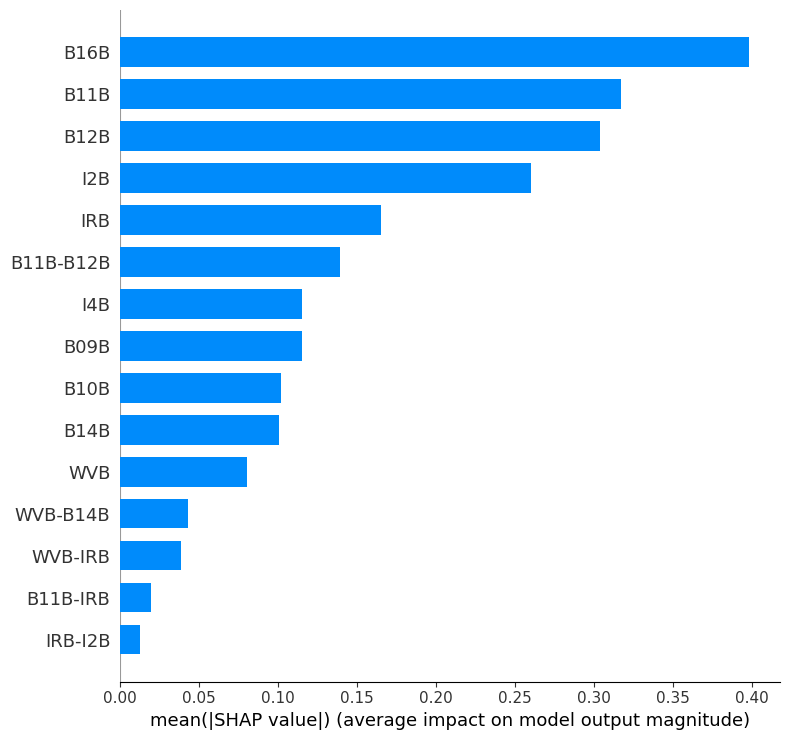

.values =
array([[ 0.00492025,  0.23090788, -0.49652355, ...,  0.04301537,
        -0.26629751,  0.02950454],
       [-0.07733208, -0.07475468, -0.00570591, ...,  0.01306154,
         0.0513931 ,  0.01445068],
       [ 0.1760698 ,  0.25427479, -0.2032463 , ...,  0.02850228,
        -0.15547959,  0.01058517],
       ...,
       [-0.04973521,  0.08819659, -0.04802293, ..., -0.01249439,
        -0.04633551,  0.0234754 ],
       [ 0.13141757,  0.17989143, -0.00603914, ...,  0.05977832,
        -0.10867228,  0.00563933],
       [-0.30184008, -0.10434478, -0.55944595, ...,  0.04393101,
        -0.18654758,  0.02937261]], shape=(2001, 15))

In [73]:
shapValue(myModel, XBackground, XTest, bandList)

In [4]:
data = pd.read_parquet("/sdd/Dubaoset/src/Phong/Source/addInput/X/X_merged_data_part_0.parquet")

In [74]:
import json
import pandas as pd

data = []

# đọc file
with open("/sdd/Dubaoset/src/Phong/Model/data/describe.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        obj = json.loads(line)  # parse từng dòng
        for band, stats in obj.items():
            stats["band"] = band  # thêm tên band
            data.append(stats)

# convert sang dataframe
df = pd.DataFrame(data)

# set index nếu muốn
df = df.set_index("band")

print(df.head())

            count        mean        std  min         25%         50%  \
band                                                                    
B04B  100135982.0    0.122141   0.166672  0.0    0.000000    0.006836   
B05B  100092799.0    0.071983   0.093988  0.0    0.000000    0.001953   
B06B   99988166.0    0.055900   0.077539  0.0    0.000000    0.001043   
VSB    99789816.0    0.100816   0.153962  0.0    0.000000    0.005859   
B09B  100334064.0  243.291443  74.266838  0.0  238.252747  248.544266   

             75%         max  
band                          
B04B    0.197647    1.198960  
B05B    0.128174    1.201820  
B06B    0.088013    1.187853  
VSB     0.123276    1.198345  
B09B  255.329544  269.292725  


In [9]:
data.describe()

,IRB-I2B_t-6,B09B-B14B_t-6,WVB-B14B_t-6,B11B-B14B_t-6,I2B-B14B_t-6,WVB-IRB_t-6,B11B-IRB_t-6,B14B-I2B_t-6,B11B-B12B_t-6,WVB-B10B_t-6,...,B09B_t-1,B10B_t-1,B11B_t-1,B12B_t-1,B14B_t-1,B16B_t-1,I2B_t-1,I4B_t-1,IRB_t-1,WVB_t-1
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.495692,0.488829,0.475628,0.488872,0.492669,0.474064,0.498737,0.507331,0.505532,0.490028,...,0.902657,0.906781,0.855153,0.890622,0.847851,0.896027,0.854525,0.711938,0.848078,0.911211
std,0.013549,0.029843,0.034021,0.016929,0.015417,0.032729,0.013179,0.015417,0.024115,0.017943,...,0.073873,0.078705,0.096820,0.071542,0.099646,0.089603,0.098496,0.064726,0.096046,0.063554
min,0.007432,0.023632,0.012701,0.006462,0.021232,0.005747,0.006713,0.024371,0.004514,0.012643,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.492251,0.470086,0.453079,0.486097,0.490691,0.452010,0.497212,0.505269,0.502791,0.482270,...,0.883613,0.887533,0.824616,0.864935,0.810496,0.866866,0.817197,0.690314,0.814838,0.892696
50%,0.495122,0.482617,0.466304,0.487710,0.492618,0.465763,0.498596,0.507382,0.512084,0.486516,...,0.922570,0.933296,0.893670,0.916077,0.889100,0.936330,0.896859,0.731022,0.887168,0.924572
75%,0.498533,0.502539,0.489451,0.491386,0.494731,0.487830,0.500368,0.509309,0.516362,0.493414,...,0.948140,0.955209,0.919282,0.936064,0.915244,0.953174,0.920957,0.750625,0.912931,0.949701
max,0.976092,0.987354,0.988128,0.973774,0.975629,0.986656,0.989824,0.978768,0.996455,0.985512,...,0.993596,0.995462,0.988955,0.991209,0.989527,0.988889,0.982101,0.809905,0.990588,0.996509


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.feature_selection import (
    mutual_info_classif,
    SequentialFeatureSelector,
    RFE
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import pointbiserialr
from evalScore import (
    eval_stepwise_forward, eval_stepwise_backward,
    eval_rfe, eval_point_biserial, eval_mutual_information, takeTimeBand
)

In [2]:
from esda.moran import Moran

In [14]:
data = pd.read_parquet("/sdd/Dubaoset/src/Phong/Source/addInput/yCol/y_merged_data_part_0.parquet")

In [15]:
list(data.columns)

['output_0', 'row', 'col']

In [16]:
data

,output_0,row,col
0,0,135,183
1,0,340,147
2,0,43,138
3,1,80,134
4,1,304,55
...,...,...,...
19995,0,174,124
19996,0,331,0
19997,0,6,121
19998,0,334,62


In [6]:
list(data.columns)

['IRB-I2B_t-6',
 'B09B-B14B_t-6',
 'WVB-B14B_t-6',
 'B11B-B14B_t-6',
 'I2B-B14B_t-6',
 'WVB-IRB_t-6',
 'B11B-IRB_t-6',
 'B14B-I2B_t-6',
 'B11B-B12B_t-6',
 'WVB-B10B_t-6',
 'B09B_t-6',
 'B10B_t-6',
 'B11B_t-6',
 'B12B_t-6',
 'B14B_t-6',
 'B16B_t-6',
 'I2B_t-6',
 'I4B_t-6',
 'IRB_t-6',
 'WVB_t-6',
 'IRB-I2B_t-5',
 'B09B-B14B_t-5',
 'WVB-B14B_t-5',
 'B11B-B14B_t-5',
 'I2B-B14B_t-5',
 'WVB-IRB_t-5',
 'B11B-IRB_t-5',
 'B14B-I2B_t-5',
 'B11B-B12B_t-5',
 'WVB-B10B_t-5',
 'B09B_t-5',
 'B10B_t-5',
 'B11B_t-5',
 'B12B_t-5',
 'B14B_t-5',
 'B16B_t-5',
 'I2B_t-5',
 'I4B_t-5',
 'IRB_t-5',
 'WVB_t-5',
 'IRB-I2B_t-4',
 'B09B-B14B_t-4',
 'WVB-B14B_t-4',
 'B11B-B14B_t-4',
 'I2B-B14B_t-4',
 'WVB-IRB_t-4',
 'B11B-IRB_t-4',
 'B14B-I2B_t-4',
 'B11B-B12B_t-4',
 'WVB-B10B_t-4',
 'B09B_t-4',
 'B10B_t-4',
 'B11B_t-4',
 'B12B_t-4',
 'B14B_t-4',
 'B16B_t-4',
 'I2B_t-4',
 'I4B_t-4',
 'IRB_t-4',
 'WVB_t-4',
 'IRB-I2B_t-3',
 'B09B-B14B_t-3',
 'WVB-B14B_t-3',
 'B11B-B14B_t-3',
 'I2B-B14B_t-3',
 'WVB-IRB_t-3',
 'B11B-

In [1]:
a = [2, 3, 4]

In [2]:
b = a[:]

In [3]:
b

[2, 3, 4]

In [4]:
fullBand = [
    "IRB-I2B", "B09B-B14B", "WVB-B14B","B11B-B14B","I2B-B14B",
    "WVB-IRB","B11B-IRB","B14B-I2B","B11B-B12B","WVB-B10B",
    "B09B","B10B","B11B","B12B","B14B","B16B","I2B","I4B","IRB","WVB"
]
timeStamps = [i for i in range(-6 , 0)]
bandList = []
for band in fullBand:
    bandList += takeTimeBand(band, timeStamps)

In [6]:
X = pd.read_parquet("/sdd/Dubaoset/src/Phong/Source/addInput/X/X_merged_data_part_0.parquet")

In [10]:
y = pd.read_parquet("/sdd/Dubaoset/src/Phong/Source/addInput/y/y_merged_data_part_0.parquet")

In [16]:
y.squeeze()

0        0
1        1
2        1
3        0
4        0
        ..
19995    0
19996    0
19997    0
19998    0
19999    0
Name: output_0, Length: 20000, dtype: int8

In [7]:
X.loc[:, bandList]

,IRB-I2B_t-6,IRB-I2B_t-5,IRB-I2B_t-4,IRB-I2B_t-3,IRB-I2B_t-2,IRB-I2B_t-1,B09B-B14B_t-6,B09B-B14B_t-5,B09B-B14B_t-4,B09B-B14B_t-3,...,IRB_t-4,IRB_t-3,IRB_t-2,IRB_t-1,WVB_t-6,WVB_t-5,WVB_t-4,WVB_t-3,WVB_t-2,WVB_t-1
0,0.496342,0.498660,0.499068,0.498897,0.498768,0.498768,0.473638,0.473853,0.474227,0.474747,...,0.918817,0.918493,0.917520,0.917520,0.948755,0.945844,0.946427,0.946427,0.946988,0.948109
1,0.492670,0.492670,0.492357,0.492670,0.492325,0.492670,0.544195,0.544195,0.541925,0.544195,...,0.618042,0.615088,0.611992,0.615088,0.768504,0.768504,0.768504,0.768504,0.768504,0.768504
2,0.494639,0.490488,0.490026,0.490984,0.490887,0.491081,0.501226,0.520237,0.520375,0.518877,...,0.825721,0.824322,0.794931,0.757599,0.959320,0.957245,0.957217,0.948998,0.927698,0.907646
3,0.493406,0.490797,0.493235,0.492989,0.493144,0.492959,0.469733,0.467997,0.468611,0.469139,...,0.897808,0.894342,0.895378,0.894978,0.910867,0.917625,0.912380,0.910867,0.910867,0.910867
4,0.498756,0.496146,0.495856,0.498340,0.495317,0.497959,0.457984,0.458213,0.459094,0.458850,...,0.942694,0.948757,0.941571,0.946675,0.955231,0.959274,0.960067,0.955764,0.959614,0.957362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.496721,0.495723,0.493547,0.491405,0.492528,0.492176,0.527357,0.528861,0.532778,0.534425,...,0.703197,0.701406,0.699085,0.706430,0.847725,0.854286,0.850445,0.855106,0.850445,0.854286
19996,0.503448,0.505378,0.505056,0.504574,0.504872,0.503425,0.488341,0.488221,0.484887,0.483707,...,0.881078,0.884770,0.892217,0.878721,0.923613,0.921787,0.925874,0.927263,0.932468,0.934474
19997,0.495939,0.496516,0.497039,0.494351,0.498398,0.497810,0.489648,0.489836,0.489044,0.487830,...,0.900854,0.897109,0.907935,0.906765,0.962492,0.963514,0.963514,0.966545,0.963514,0.963514
19998,0.494227,0.494361,0.494343,0.493777,0.494454,0.493700,0.469924,0.469710,0.469525,0.470885,...,0.920106,0.920106,0.921386,0.921386,0.941016,0.941609,0.941609,0.943953,0.943953,0.943367


In [11]:
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    max_samples=0.8,
    n_jobs=1,
    class_weight="balanced",
    random_state=42
)

In [17]:
result = eval_stepwise_forward(model= model, X= X, y= y.squeeze(),timeStamps= timeStamps, bandList= fullBand)

KeyboardInterrupt: 

In [5]:
bandList

['IRB-I2B_t-6',
 'IRB-I2B_t-5',
 'IRB-I2B_t-4',
 'IRB-I2B_t-3',
 'IRB-I2B_t-2',
 'IRB-I2B_t-1',
 'B09B-B14B_t-6',
 'B09B-B14B_t-5',
 'B09B-B14B_t-4',
 'B09B-B14B_t-3',
 'B09B-B14B_t-2',
 'B09B-B14B_t-1',
 'WVB-B14B_t-6',
 'WVB-B14B_t-5',
 'WVB-B14B_t-4',
 'WVB-B14B_t-3',
 'WVB-B14B_t-2',
 'WVB-B14B_t-1',
 'B11B-B14B_t-6',
 'B11B-B14B_t-5',
 'B11B-B14B_t-4',
 'B11B-B14B_t-3',
 'B11B-B14B_t-2',
 'B11B-B14B_t-1',
 'I2B-B14B_t-6',
 'I2B-B14B_t-5',
 'I2B-B14B_t-4',
 'I2B-B14B_t-3',
 'I2B-B14B_t-2',
 'I2B-B14B_t-1',
 'WVB-IRB_t-6',
 'WVB-IRB_t-5',
 'WVB-IRB_t-4',
 'WVB-IRB_t-3',
 'WVB-IRB_t-2',
 'WVB-IRB_t-1',
 'B11B-IRB_t-6',
 'B11B-IRB_t-5',
 'B11B-IRB_t-4',
 'B11B-IRB_t-3',
 'B11B-IRB_t-2',
 'B11B-IRB_t-1',
 'B14B-I2B_t-6',
 'B14B-I2B_t-5',
 'B14B-I2B_t-4',
 'B14B-I2B_t-3',
 'B14B-I2B_t-2',
 'B14B-I2B_t-1',
 'B11B-B12B_t-6',
 'B11B-B12B_t-5',
 'B11B-B12B_t-4',
 'B11B-B12B_t-3',
 'B11B-B12B_t-2',
 'B11B-B12B_t-1',
 'WVB-B10B_t-6',
 'WVB-B10B_t-5',
 'WVB-B10B_t-4',
 'WVB-B10B_t-3',
 'WVB-B1

In [3]:
import numpy as np
a = np.arange(10)
active_mask = np.ones(10, dtype=bool)

In [4]:
active_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [5]:
a[active_mask]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [12]:
array = [[i for i in range(60)], [j for j in range(60,120)]]

In [13]:
importance = np.mean(np.abs(array), axis=0)

In [14]:
importance

array([30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42.,
       43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55.,
       56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68.,
       69., 70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81.,
       82., 83., 84., 85., 86., 87., 88., 89.])

In [20]:
perStep = np.squeeze([[np.mean(np.abs(importance[i : i + 6])) for i in range(0, len(importance), 6)]])

In [ ]:
perStep

array([32.5, 38.5, 44.5, 50.5, 56.5, 62.5, 68.5, 74.5, 80.5, 86.5])

In [22]:
perStep[[2,3]]

array([44.5, 50.5])

In [2]:
infraredList = ["I4B", "WVB", "B09B", "B10B", "B11B", "B12B", "IRB", "B14B", "I2B", "B16B"]
header = ['I4B-WVB', 'I4B-B09B', 'I4B-B10B', 'I4B-B11B', 'I4B-B12B', 'I4B-IRB', 'I4B-B14B', 'I4B-I2B', 'I4B-B16B', 'WVB-B09B', 'WVB-B10B', 'WVB-B11B', 'WVB-B12B', 'WVB-IRB', 'WVB-B14B', 'WVB-I2B', 'WVB-B16B', 'B09B-B10B', 'B09B-B11B', 'B09B-B12B', 'B09B-IRB', 'B09B-B14B', 'B09B-I2B', 'B09B-B16B', 'B10B-B11B', 'B10B-B12B', 'B10B-IRB', 'B10B-B14B', 'B10B-I2B', 'B10B-B16B', 'B11B-B12B', 'B11B-IRB', 'B11B-B14B', 'B11B-I2B', 'B11B-B16B', 'B12B-IRB', 'B12B-B14B', 'B12B-I2B', 'B12B-B16B', 'IRB-B14B', 'IRB-I2B', 'IRB-B16B', 'B14B-I2B', 'B14B-B16B', 'I2B-B16B']
bandType = [
    'B09B(10)','B10B(10)','B11B(10)','B12B(10)','B14B(10)','B16B(10)',
    'I2B(10)','I4B(10)','IRB(10)','WVB(10)',
    'B09B(20)','B10B(20)','B11B(20)','B12B(20)','B14B(20)','B16B(20)',
    'I2B(20)','I4B(20)','IRB(20)','WVB(20)',
    'B09B(30)','B10B(30)','B11B(30)','B12B(30)','B14B(30)','B16B(30)',
    'I2B(30)','I4B(30)','IRB(30)','WVB(30)',
    'B09B(40)','B10B(40)','B11B(40)','B12B(40)','B14B(40)','B16B(40)',
    'I2B(40)','I4B(40)','IRB(40)','WVB(40)',
    'B09B(50)','B10B(50)','B11B(50)','B12B(50)','B14B(50)','B16B(50)',
    'I2B(50)','I4B(50)','IRB(50)','WVB(50)',
    'B09B(60)','B10B(60)','B11B(60)','B12B(60)','B14B(60)','B16B(60)',
    'I2B(60)','I4B(60)','IRB(60)','WVB(60)'
]

top20 = ['B11B',
 'IRB',
 'B12B',
 'B14B',
 'I2B',
 'B16B',
 'B10B',
 'B11B-B12B',
 'B12B-IRB',
 'I2B-B16B',
 'B14B-B16B',
 'WVB-IRB',
 'B09B',
 'WVB-B11B',
 'WVB-B10B',
 'WVB-B14B',
 'B09B-IRB',
 'WVB-I2B',
 'IRB-B16B',
 'B12B-B14B']
 
bandType10 = ['B09B(10)','B10B(10)','B11B(10)','B12B(10)','B14B(10)','B16B(10)',
    'I2B(10)','I4B(10)','IRB(10)','WVB(10)']
bandType20 = ['B09B(20)','B10B(20)','B11B(20)','B12B(20)','B14B(20)','B16B(20)',
 'I2B(20)','I4B(20)','IRB(20)','WVB(20)']
bandType30 = ['B09B(30)','B10B(30)','B11B(30)','B12B(30)','B14B(30)','B16B(30)',
 'I2B(30)','I4B(30)','IRB(30)','WVB(30)']
bandType40 = ['B09B(40)','B10B(40)','B11B(40)','B12B(40)','B14B(40)','B16B(40)',
 'I2B(40)','I4B(40)','IRB(40)','WVB(40)']
bandType50 = ['B09B(50)','B10B(50)','B11B(50)','B12B(50)','B14B(50)','B16B(50)',
 'I2B(50)','I4B(50)','IRB(50)','WVB(50)']
bandType60 = ['B09B(60)','B10B(60)','B11B(60)','B12B(60)','B14B(60)','B16B(60)',
 'I2B(60)','I4B(60)','IRB(60)','WVB(60)']

In [3]:
def appendTime(band):
    result = []
    for item in band:
        for i in range(10, 70, 10):
            data = f"{item}({i})"
            result.append(data)
    return result

In [4]:
df = pd.read_csv("/sdd/Dubaoset/src/Phong/merged_train.csv", chunksize= 5000000)
data = next(df)

In [5]:
data = data.dropna()
data = data.reset_index(drop= True)

In [6]:
import pandas as pd

def calDiff(df, header):
    new_cols = {}

    for head in header:
        bandMinus, bandBeMinus = head.split("-")
        for i in range(10, 70, 10):
            col_name = f"{head}({i})"
            new_cols[col_name] = df[f"{bandMinus}({i})"] - df[f"{bandBeMinus}({i})"]

    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)


In [7]:
data = calDiff(data, header)

In [8]:
data

,B04B(10),B05B(10),B06B(10),B09B(10),B10B(10),B11B(10),B12B(10),B14B(10),B16B(10),I2B(10),...,B14B-B16B(30),B14B-B16B(40),B14B-B16B(50),B14B-B16B(60),I2B-B16B(10),I2B-B16B(20),I2B-B16B(30),I2B-B16B(40),I2B-B16B(50),I2B-B16B(60)
0,0.048904,0.038132,0.027374,249.66998,259.59558,293.73254,271.45502,295.96503,274.19080,292.18143,...,21.25524,21.56723,21.67120,21.77322,17.99063,17.54492,17.54492,17.76780,17.87920,17.87920
1,0.247543,0.151657,0.082169,247.62251,256.09665,289.76385,270.15503,289.79462,268.39996,284.71000,...,20.71455,20.84825,20.88971,20.52085,16.31004,16.26636,15.92435,15.72993,15.78333,15.30326
2,0.552826,0.186874,0.259262,210.30916,209.09041,209.60748,220.17198,208.53848,209.21332,207.99033,...,0.49942,0.78775,0.82895,2.02109,-1.22299,-0.41586,-0.17726,-0.16226,0.20789,0.97325
3,0.000000,0.000000,0.000000,224.16125,227.01600,232.52335,231.79323,228.61462,224.12857,226.58995,...,6.48327,11.04425,14.50196,15.51514,2.46138,3.12254,3.73367,6.85067,9.84262,10.55172
4,0.000000,0.000000,0.000000,250.54999,259.93335,288.77814,267.64250,290.77716,271.53082,288.21430,...,19.19516,19.22354,19.06458,19.19834,16.68348,16.56781,16.52942,16.58444,16.54550,16.56498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4442029,0.000000,0.000000,0.000000,235.63202,242.30112,268.11877,252.97490,263.64676,247.45572,258.38275,...,14.64113,13.19739,12.28642,9.53677,10.92703,9.75737,9.70763,8.60715,8.06148,6.04045
4442030,0.429535,0.312103,0.182938,243.44000,251.71000,282.04858,261.30542,283.41293,265.05276,279.76462,...,18.50345,17.96788,16.71435,16.96438,14.71186,14.34390,14.39673,13.93730,12.41839,12.55930
4442031,0.029358,0.017578,0.009766,245.96002,254.62000,291.34564,270.68005,292.59998,270.99414,287.75160,...,21.82750,21.93416,21.66333,21.87665,16.75746,16.83443,16.83443,16.83443,16.79593,16.91207
4442032,0.074341,0.064575,0.029358,255.05502,263.48206,290.06903,264.61636,292.81300,272.60254,290.04077,...,19.89078,19.78412,19.46414,19.46414,17.43823,17.32446,17.32446,17.32446,17.32446,17.32446


In [ ]:
finalHeader = appendTime(top20)

In [10]:
X = data.loc[:, finalHeader].copy()
y = data.loc[:,"label lightning"].copy()

In [11]:
num = len(X.columns)
num

120

In [12]:
X

,B11B(10),B11B(20),B11B(30),B11B(40),B11B(50),B11B(60),IRB(10),IRB(20),IRB(30),IRB(40),...,IRB-B16B(30),IRB-B16B(40),IRB-B16B(50),IRB-B16B(60),B12B-B14B(10),B12B-B14B(20),B12B-B14B(30),B12B-B14B(40),B12B-B14B(50),B12B-B14B(60)
0,293.73254,293.35754,293.16864,293.54504,293.82630,293.73254,296.80502,296.10938,296.30810,296.50687,...,22.11730,22.31607,22.51486,22.41546,-24.51001,-24.61002,-24.63598,-24.55803,-24.66200,-24.89402
1,289.76385,289.35680,287.74817,286.80716,286.08255,284.94485,291.83582,291.41450,289.73047,288.54404,...,22.86002,22.93724,23.35487,23.05674,-19.63959,-19.34961,-18.74915,-18.29407,-17.73309,-17.03965
2,209.60748,213.66249,216.48074,216.91449,220.26874,223.19308,209.72850,213.07697,216.81601,217.39185,...,0.97209,1.29293,1.48937,2.85091,11.63350,8.78967,6.50165,5.95832,5.20247,3.51498
3,232.52335,235.36792,238.93288,252.20479,262.44620,265.48566,231.59572,233.81758,237.39438,251.19661,...,10.51118,15.41757,18.75468,19.88176,3.17861,2.63150,2.13853,-2.81023,-6.76194,-7.97948
4,288.77814,288.67874,288.87753,289.17566,289.37440,289.57312,291.00867,291.11350,291.21884,291.63516,...,19.41968,19.43390,19.27122,19.40498,-23.13466,-23.02608,-23.35182,-23.64648,-23.48336,-23.61921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888538,243.18001,239.60680,233.54834,230.63501,230.87000,230.89708,242.74709,239.20750,233.58179,230.45142,...,3.21024,2.51767,2.93382,3.41222,-4.67844,-4.32635,-1.90969,-0.85001,-0.88148,-0.34210
888539,291.73560,291.73560,291.73560,291.73560,291.73560,291.73560,294.30603,294.40802,294.40802,294.40802,...,24.09134,24.49884,24.19282,24.19282,-25.64664,-25.75330,-25.75330,-25.53998,-25.19082,-25.19082
888540,265.88260,270.03833,271.08250,259.28983,251.25153,255.49060,267.20258,272.00000,273.13770,259.75450,...,14.63428,14.65608,13.22310,12.95037,-14.35089,-16.96183,-16.75994,-9.49577,-5.08278,-7.71211
888541,283.68048,284.43002,284.96335,285.17667,285.17667,285.38800,285.19897,285.97000,286.51965,286.84750,...,25.64515,25.82663,25.97407,26.04483,-18.49527,-18.79538,-19.32556,-19.41611,-19.13248,-19.24863


In [9]:
def eval_mutual_information(X, y, random_state=42):
    mi = mutual_info_classif(X, y, random_state=random_state)
    return (
        pd.DataFrame({
            "feature": X.columns,
            "MI_score": mi
        })
        .sort_values("MI_score", ascending=False)
        .reset_index(drop=True)
    )

def eval_point_biserial(X, y):
    scores = []

    for col in X.columns:
        corr, pval = pointbiserialr(y, X[col])
        scores.append({
            "feature": col,
            "PBC_corr": abs(corr),
            "p_value": pval
        })

    return (
        pd.DataFrame(scores)
        .sort_values("PBC_corr", ascending=False)
        .reset_index(drop=True)
    )

def eval_stepwise_forward(
    X, y,
    n_features=20,
    scoring="average_precision",
    cv=5,
    random_state=42
):
    model = RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        max_features="sqrt",
        max_samples=0.5,
        n_jobs=1,
        bootstrap=True,
        oob_score=False,
        class_weight='balanced',
        random_state=42
    )

    sfs = SequentialFeatureSelector(
        model,
        n_features_to_select=n_features,
        direction="forward",
        scoring=scoring,
        cv=cv,
        n_jobs=-1
    )

    sfs.fit(X, y)

    return pd.DataFrame({
        "feature": X.columns,
        "selected": sfs.get_support()
    }).sort_values("selected", ascending=False)

def eval_stepwise_backward(
    X, y,
    n_features=20,
    scoring="average_precision",
    cv=5,
    random_state=42
):
    model = RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        max_features="sqrt",
        max_samples=0.5,
        n_jobs=1,
        bootstrap=True,
        oob_score=False,
        class_weight='balanced',
        random_state=42
    )

    sfs = SequentialFeatureSelector(
        model,
        n_features_to_select=n_features,
        direction="backward",
        scoring=scoring,
        cv=cv,
        n_jobs=-1
    )

    sfs.fit(X, y)

    return pd.DataFrame({
        "feature": X.columns,
        "selected": sfs.get_support()
    }).sort_values("selected", ascending=False)

def eval_rfe(
    X, y,
    n_features=20,
    max_iter=500
):
    model = LogisticRegression(max_iter=max_iter)

    rfe = RFE(
        estimator=model,
        n_features_to_select=n_features
    )

    rfe.fit(X, y)

    return (
        pd.DataFrame({
            "feature": X.columns,
            "ranking": rfe.ranking_,
            "selected": rfe.support_
        })
        .sort_values("ranking")
        .reset_index(drop=True)
    )


In [10]:
top20 = [f"{x}(10)" for x in top20]

In [11]:
X = data.loc[:, top20].copy()

In [12]:
X 

,B11B(10),IRB(10),B12B(10),B14B(10),I2B(10),B16B(10),B10B(10),B11B-B12B(10),B12B-IRB(10),I2B-B16B(10),B14B-B16B(10),WVB-IRB(10),B09B(10),WVB-B11B(10),WVB-B10B(10),WVB-B14B(10),B09B-IRB(10),WVB-I2B(10),IRB-B16B(10),B12B-B14B(10)
0,293.73254,296.80502,271.45502,295.96503,292.18143,274.19080,259.59558,22.27752,-25.35000,17.99063,21.77423,-57.34170,249.66998,-54.26922,-20.13226,-56.50171,-47.13504,-52.71811,22.61422,-24.51001
1,289.76385,291.83582,270.15503,289.79462,284.71000,268.39996,256.09665,19.60882,-21.68079,16.31004,21.39466,-55.39246,247.62251,-53.32049,-19.65329,-53.35126,-44.21331,-48.26664,23.43586,-19.63959
2,209.60748,209.72850,220.17198,208.53848,207.99033,209.21332,209.09041,-10.56450,10.44348,-1.22299,-0.67484,-0.65933,210.30916,-0.53831,-0.02124,0.53069,0.58066,1.07884,0.51518,11.63350
3,232.52335,231.59572,231.79323,228.61462,226.58995,224.12857,227.01600,0.73012,0.19751,2.46138,4.48605,-11.43172,224.16125,-12.35935,-6.85200,-8.45062,-7.43447,-6.42595,7.46715,3.17861
4,288.77814,291.00867,267.64250,290.77716,288.21430,271.53082,259.93335,21.13564,-23.36617,16.68348,19.24634,-52.22980,250.54999,-49.99927,-21.15448,-51.99829,-40.45868,-49.43543,19.47785,-23.13466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4442029,268.11877,268.29330,252.97490,263.64676,258.38275,247.45572,242.30112,15.14387,-15.31840,10.92703,16.19104,-40.42471,235.63202,-40.25018,-14.43253,-35.77817,-32.66128,-30.51416,20.83758,-10.67186
4442030,282.04858,284.53146,261.30542,283.41293,279.76462,265.05276,251.71000,20.74316,-23.22604,14.71186,18.36017,-50.81645,243.44000,-48.33357,-17.99499,-49.69792,-41.09146,-46.04961,19.47870,-22.10751
4442031,291.34564,294.00000,270.68005,292.59998,287.75160,270.99414,254.62000,20.66559,-23.31995,16.75746,21.60584,-58.10999,245.96002,-55.45563,-18.72999,-56.70997,-48.03998,-51.86159,23.00586,-21.91993
4442032,290.06903,292.87534,264.61636,292.81300,290.04077,272.60254,263.48206,25.45267,-28.25898,17.43823,20.21046,-48.27262,255.05502,-45.46631,-18.87934,-48.21028,-37.82032,-45.43805,20.27280,-28.19664


In [13]:
X = X.corr()

In [15]:
X

,B11B(10),IRB(10),B12B(10),B14B(10),I2B(10),B16B(10),B10B(10),B11B-B12B(10),B12B-IRB(10),I2B-B16B(10),B14B-B16B(10),WVB-IRB(10),B09B(10),WVB-B11B(10),WVB-B10B(10),WVB-B14B(10),B09B-IRB(10),WVB-I2B(10),IRB-B16B(10),B12B-B14B(10)
B11B(10),1.000000,0.999483,0.995023,0.998128,0.996009,0.992041,0.976123,0.989416,-0.990912,0.974662,0.968502,-0.975807,0.959319,-0.974004,-0.950779,-0.976113,-0.963085,-0.975162,0.948349,-0.985647
IRB(10),0.999483,1.000000,0.995305,0.999169,0.997472,0.993555,0.976004,0.987745,-0.991732,0.975895,0.968099,-0.976897,0.959371,-0.973497,-0.951298,-0.978020,-0.964000,-0.977798,0.945977,-0.987676
B12B(10),0.995023,0.995305,1.000000,0.994618,0.991574,0.986169,0.963043,0.970031,-0.974655,0.975425,0.972130,-0.979644,0.943576,-0.977095,-0.945656,-0.981011,-0.970116,-0.979108,0.949318,-0.970935
B14B(10),0.998128,0.999169,0.994618,1.000000,0.999118,0.995960,0.977438,0.985440,-0.990721,0.974820,0.964245,-0.973969,0.961155,-0.969608,-0.950390,-0.977660,-0.960767,-0.978662,0.935950,-0.990508
I2B(10),0.996009,0.997472,0.991574,0.999118,1.000000,0.997783,0.980715,0.984706,-0.990834,0.972370,0.955420,-0.968258,0.965896,-0.962975,-0.950223,-0.973192,-0.953128,-0.976770,0.924305,-0.992508
B16B(10),0.992041,0.993555,0.986169,0.995960,0.997783,1.000000,0.987619,0.982901,-0.988947,0.954678,0.936551,-0.955113,0.975038,-0.949166,-0.948204,-0.961175,-0.937194,-0.965676,0.903127,-0.992383
B10B(10),0.976123,0.976004,0.963043,0.977438,0.980715,0.987619,1.000000,0.977764,-0.979043,0.921769,0.900791,-0.913103,0.995367,-0.908193,-0.938404,-0.917508,-0.885250,-0.922656,0.872061,-0.980279
B11B-B12B(10),0.989416,0.987745,0.970031,0.985440,0.984706,0.982901,0.977764,1.000000,-0.996916,0.956171,0.945949,-0.952819,0.965137,-0.952135,-0.941284,-0.951574,-0.935672,-0.952025,0.930028,-0.989494
B12B-IRB(10),-0.990912,-0.991732,-0.974655,-0.990721,-0.990834,-0.988947,-0.979043,-0.996916,1.000000,-0.962373,-0.948723,0.959097,-0.966410,0.954619,0.944990,0.959880,0.941921,0.961891,-0.927838,0.995559
I2B-B16B(10),0.974662,0.975895,0.975425,0.974820,0.972370,0.954678,0.921769,0.956171,-0.962373,1.000000,0.987783,-0.980085,0.899625,-0.977323,-0.923659,-0.980888,-0.975275,-0.981100,0.965869,-0.957803


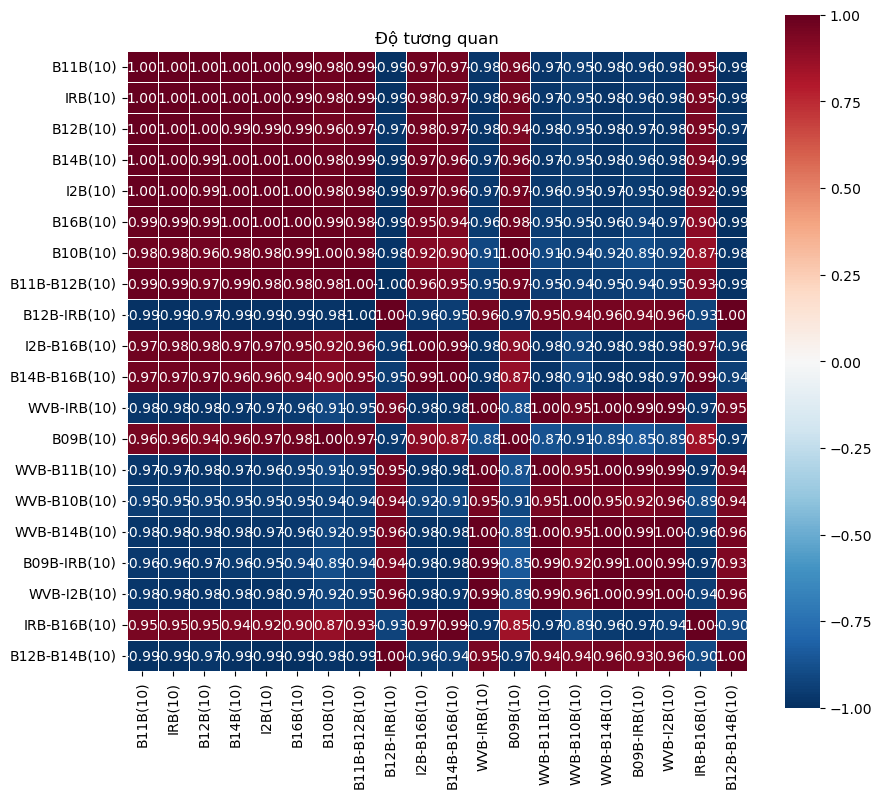

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize= (10, 9))
sns.heatmap(
    X,
    annot=True,          # hiển thị giá trị
    fmt=".2f",            # 2 chữ số thập phân
    cmap="RdBu_r",        # màu đối xứng
    vmin=-1, vmax=1,     # chuẩn hóa thang màu
    square=True,         # ô vuông
    linewidths=0.5
)
plt.title("Độ tương quan")
plt.show()

In [27]:
SF = eval_mutual_information(X, y)

In [28]:
SF.to_csv("/sdd/Dubaoset/src/Phong/Source/addInput/evaluateMI.csv", mode="a", header= True)

In [14]:
X.to_csv("/sdd/Dubaoset/src/Phong/Source/addInput/X.csv", header= True, index= False)
y.to_csv("/sdd/Dubaoset/src/Phong/Source/addInput/y.csv", header= True, index= False)